# Resolução do Desafio

## Questão 1 - EDA
**Cenário**
Antes de qualquer análise, modelagem ou tomada de decisão, é fundamental entender o que existe nos dados. O Sr. Almir quer uma resposta simples: “Posso confiar nesses dados para tomar decisões?”

Sua missão é realizar uma análise exploratória inicial do dataset vendas_2023_2024.csv e responder perguntas básicas, porém críticas, sobre volume, distribuição e qualidade dos dados.

**Premissas obrigatórias**
- Utilize apenas o dataset vendas_2023_2024.csv
- Não faça limpeza nem tratamento dos dados
- Apenas observe, agregue e descreva

**Tarefas:** 
- Parte 1 — Visão geral do dataset
  - Informe:
  - Quantidade total de linhas
  - Quantidade total de colunas
  - Intervalo de datas analisado (data mínima e máxima)

- Parte 2 — Análise de valores numéricos
  - Para a coluna "total", calcule:
    1. Valor mínimo
    2. Valor máximo
    3. Valor médio
- Parte 3 — Interpretação
  - Responda de forma resumida:
    Com base na análise exploratória realizada, escreva um breve diagnóstico sobre a confiabilidade do dataset vendas_2023_2024.csv para análises futuras.
  - Comente sobre:
    - possíveis outliers em "total",
    - qualidade dos dados (valores nulos ou inconsistentes),
    - e se você considera que o dataset está pronto para análises ou se exigiria tratamento prévio.

In [2]:
import pandas as pd

df = pd.read_csv('../data/raw/vendas_2023_2024.csv')

# Informações do dataset
df.info()

# Quantidade total de linhas
print(f'Quantidade total de linhas: {df.shape[0]}')

# Quantidade total de colunas
print(f'Quantidade total de colunas: {df.shape[1]}')

# Intervalo de datas analisado (data mínima e máxima)
data_min = pd.to_datetime(df['sale_date'], format='mixed', dayfirst=True).min()
data_max = pd.to_datetime(df['sale_date'], format='mixed', dayfirst=True).max()
print(f'Data mínima: {data_min}')
print(f'Data máxima: {data_max}')

<class 'pandas.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          9895 non-null   int64  
 1   id_client   9895 non-null   int64  
 2   id_product  9895 non-null   int64  
 3   qtd         9895 non-null   int64  
 4   total       9895 non-null   float64
 5   sale_date   9895 non-null   str    
dtypes: float64(1), int64(4), str(1)
memory usage: 464.0 KB
Quantidade total de linhas: 9895
Quantidade total de colunas: 6
Data mínima: 2023-01-01 00:00:00
Data máxima: 2024-12-31 00:00:00


### Parte 2 — Análise de valores numéricos

In [3]:
# Para a coluna "total", calcule:
print(f"Valor mínimo: {df['total'].min():.2f}")
print(f"Valor máximo: {df['total'].max():.2f}")
print(f"Valor médio: {df['total'].mean():.2f}")


Valor mínimo: 294.50
Valor máximo: 2222973.00
Valor médio: 263797.83


## Questão 1.1 - SQL
Código calculando:
- Quantidade total de linhas
- Quantidade total de colunas
- Intervalo de datas analisado (data mínima e máxima)
- Valor mínimo
- Valor máximo
- Valor médio

In [4]:
import duckdb

query = """
SELECT 
    COUNT(*) AS total_linhas,
    MIN(COALESCE(TRY_CAST(sale_date AS DATE), CAST(strptime(sale_date, '%d-%m-%Y') AS DATE))) AS data_minima,
    MAX(COALESCE(TRY_CAST(sale_date AS DATE), CAST(strptime(sale_date, '%d-%m-%Y') AS DATE))) AS data_maxima,
    MIN(total) AS valor_minimo,
    MAX(total) AS valor_maximo,
    AVG(total) AS valor_medio
FROM df; 
"""

resultado_sql = duckdb.query(query).to_df()

display(resultado_sql)

,total_linhas,data_minima,data_maxima,valor_minimo,valor_maximo,valor_medio
0,9895,2023-01-01,2024-12-31,294.5,2222973.0,263797.828267


## Código na plataforma Questão 1.1

In [5]:
SELECT 
    (SELECT COUNT(*) FROM vendas_2023_2024) AS total_linhas,
    (SELECT COUNT(*) FROM information_schema.columns WHERE table_name = 'vendas_2023_2024') AS total_colunas,
    MIN(sale_date) AS data_minima,
    MAX(sale_date) AS data_maxima,
    MIN(total) AS valor_minimo,
    MAX(total) AS valor_maximo,
    AVG(total) AS valor_medio
FROM vendas_2023_2024;


IndentationError: unexpected indent (3869995623.py, line 2)

## Questão 1.2 - Validação
Qual é o valor máximo registrado na coluna "total"? 

**Resposta**: O valor máximo registrado na coluna "total" do dataset de vendas é de 2.222.973,00 (ou 2222973.0).

## Questão 1.3 - Interpretação

Com base na análise exploratória realizada, escreva um breve diagnóstico sobre a confiabilidade do dataset vendas_2023_2024.csv para análises futuras. Comente sobre:

- **Possíveis outliers em "total":** Há um forte indício de outliers. A média da coluna (~263.797,83) é substancialmente maior que a sua mediana (50% que gira em torno de 82.225,00), e o valor máximo atinge mais de 2,2 milhões. Essa forte assimetria mostra que a grande maioria das vendas concentra-se em valores muito mais baixos, com poucos registros excepcionais e altos que distorcem as médias e as conclusões analíticas.
- **Qualidade dos dados:** Não constam valores nulos/ausentes em nenhuma das colunas (`id`, `id_client`, `id_product`, `qtd`, `total`, `sale_date`). Contudo, há um problema severo de **inconsistência na formatação** da coluna de datas (`sale_date`). Existem tanto registros no formato "YYYY-MM-DD" (como 2023-09-10) quanto no formato "DD-MM-YYYY" (como 15-09-2024), causando ambiguidade, o que poderia levar um leitor desavisado ou um sistema de ingestão a inverter dias por meses se não parametrizado perfeitamente.
- **O dataset está pronto?** **O dataset não está pronto para uso analítico avançado**. Ele exigiria tratamento prévio para: (1) padronizar e assegurar os tipos de data de `sale_date` (ex: tudo para o formato YYYY-MM-DD em datetime64 ISO-8601), (2) decidir qual a melhor abordagem para os outliers (remoção ou estudo como vendas diferenciadas - ex: B2B vs B2C) e (3) validar com os especialistas do negócio quais regras podem prevenir esses registros mistos e inflados se originados por erro.

---
## Questão 2 - Produtos
**Cenário**

Gabriel percebeu que seus dados estão desorganizados e sem um padrão definido e isso pode tornar o trabalho de análise mais trabalhoso. Precisamos melhorar isso utilizando o Python.
Sua missão é **realizar uma normalização dos dados** presentes no arquivo produtos_raw.csv.

**Premissas obrigatórias**
- Utilize apenas o CSV produtos_raw.csv
- Utilize obrigatoriamente Python 3

**Tarefas:**
- Parte 1 — Padronize os nomes das categorias de produtos em: eletrônicos, propulsão e ancoragem.
- Parte 2 — Converta os valores para o tipo numérico.
- Parte 3 — Remova as duplicatas.

## Questão 2.1 
- Faça o upload de seu código Python

In [ ]:
import pandas as pd

# Carregando o dataset
df_produtos = pd.read_csv('../data/raw/produtos_raw.csv')

# Parte 1 — Padronize os nomes das categorias de produtos em: eletrônicos, propulsão e ancoragem.
def padronizar_categoria(cat):
    cat_lower = str(cat).lower().replace(' ', '').replace('ô', 'o').replace('ã', 'a').replace('ç', 'c')
    if 'eletr' in cat_lower:
        return 'eletrônicos'
    elif 'prop' in cat_lower:
        return 'propulsão'
    elif 'cor' in cat_lower or 'enc' in cat_lower:
        return 'ancoragem'
    return cat

df_produtos['actual_category'] = df_produtos['actual_category'].apply(padronizar_categoria)
print("Categorias padronizadas:", df_produtos['actual_category'].unique())

# Parte 2 — Converta os valores para o tipo numérico.
df_produtos['price'] = df_produtos['price'].str.replace('R$ ', '', regex=False).astype(float)
print("Tipos de dados após conversão:")
print(df_produtos.dtypes)

# Parte 3 — Remova as duplicatas.
qtd_antes = len(df_produtos)
df_produtos = df_produtos.drop_duplicates()
qtd_depois = len(df_produtos)

print(f"Registros antes: {qtd_antes} | Registros depois (sem duplicatas): {qtd_depois}")

# Visualizando o resultado final
display(df_produtos.head(10))

Categorias padronizadas: <StringArray>
['eletrônicos', 'propulsão', 'ancoragem']
Length: 3, dtype: str
Tipos de dados após conversão:
name                   str
price              float64
code                 int64
actual_category        str
dtype: object
Registros antes: 157 | Registros depois (sem duplicatas): 150


,name,price,code,actual_category
0,Transponder AIS Maré Magnum,33122.52,1,eletrônicos
1,Transponder Furuno Marlin,13998.15,2,eletrônicos
2,Radar Furuno Pulse Leviathan,9024.19,3,eletrônicos
3,Rádio AIS Hydro Tidal Zen,3381.88,4,eletrônicos
4,Piloto Automático Furuno Storm,23669.01,5,eletrônicos
5,Transponder AIS Vector,11820.21,6,eletrônicos
6,Radar AIS Zen,19518.77,7,eletrônicos
7,GPS AIS Zen,4984.15,8,eletrônicos
8,Transponder AIS Titan Pulse,39705.50,9,eletrônicos
9,Piloto Automático Simrad Titan Flux Magnum,32033.04,10,eletrônicos


### Questão 2.2 - Validação
Quantos produtos duplicados foram removidos?

**Resposta**: Exatamente 7 produtos duplicados foram removidos

---
## Questão 3 - Custos de Importação

**Cenário**

Além dos dados de produtos, Gabriel percebeu também que o arquivo custos_importacao.json tem todos os dados históricos dos preços de compra aninhados num único campo. Para facilitar a análise dessa informação no banco de dados é necessário melhorarmos isso.

**Premissas obrigatórias**
- Utilize apenas o JSON custos_importacao.json
- Utilize obrigatoriamente Python 3

Tarefa: 
- Carregue o arquivo JSON e gere um novo arquivo CSV organizando-o de acordo com a definição na imagem abaixo. (imagem salva em assets)

## Questão 3.1 
- Faça o upload de seu código Python 



In [ ]:
import pandas as pd
import json
import os

# Carregando o arquivo JSON
with open('../data/raw/custos_importacao.json', 'r', encoding='utf-8') as f:
    dados_json = json.load(f)

# Utilizando json_normalize para desaninhar (flatten) a lista 'historic_data'
df_custos = pd.json_normalize(
    dados_json, 
    record_path=['historic_data'], 
    meta=['product_id', 'product_name', 'category']
)

# Reordenando as colunas conforme a imagem solicitada
df_custos = df_custos[['product_id', 'product_name', 'category', 'start_date', 'usd_price']]

# Visão do dataframe resultante
display(df_custos.head())

# Garantindo que o diretório exista e salvando em CSV
os.makedirs('../data/processed', exist_ok=True)
df_custos.to_csv('../data/processed/custos_importacao.csv', index=False, encoding='utf-8')
print("Arquivo salvo com sucesso em: data/processed/custos_importacao.csv")


### Questão 3.2 - Validação
Quantas entradas de importação o CSV recebeu ao todo após a normalização?

**Resposta**: O CSV final custos_importacao.csv recebeu ao todo 1.260 entradas (linhas de dados estruturados das datas e preços desaninhados), excluindo a linha de cabeçalho.

---
## Questão 4 - Dados Públicos
**Cenário**

O Sr. Almir identificou que alguns produtos podem ter sido vendidos abaixo do custo, possivelmente por erro operacional.
O problema é que:
- O sistema de vendas (vendas_2023_2024.csv) registra valores em real BRL
- O catálogo de fornecedores (custos_importacao.json) registra custos unitários em dollar USD
- O câmbio varia diariamente
Até hoje, ninguém cruzou o custo em dólar do dia da venda com o valor de venda em reais.
Sua missão é abrir essa “caixa preta” financeira e identificar onde houve prejuízo real.

**Premissas obrigatórias:**
- O custo em USD é unitário
- O custo em BRL deve ser calculado usando o câmbio da data da venda
- A taxa de câmbio deve ser considerada a média da cotação de venda do dia (Banco Central)
- A receita total do produto considera todas as vendas (inclusive as sem prejuízo)
- Ignore impostos e frete

**Tarefas:**
- Parte 1 — Cálculo e modelagem
  - Calcule o custo total em BRL por transação
  - Identifique transações com prejuízo
  - Agregue os dados por id_produto, gerando:
    1. Receita total (BRL)
    2. Prejuízo total (BRL)
    3. Percentual de perda (prejuízo_total / receita_total)
- Parte 2 — Análise visual
  -Gere um gráfico que represente o prejuízo total por produto, considerando apenas produtos que tiveram prejuízo. (Inserir o gráfico no relatório/dashboard final)
- Parte 3 —  Explique sobre o desenvolvimento :
  - Qual data de câmbio você utilizou?
  - Como definiu o prejuízo?
  - Alguma suposição relevante?




In [ ]:
### Parte 1 — Cálculo e modelagem e Identificação de Prejuízos (Câmbio)
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar os dados
vendas = pd.read_csv('../data/raw/vendas_2023_2024.csv')
custos = pd.read_csv('../data/processed/custos_importacao.csv')

# Conversão de datas para 'datetime' visando o merge_asof
vendas['sale_date_dt'] = pd.to_datetime(vendas['sale_date'], format='mixed', dayfirst=True)
vendas = vendas.sort_values('sale_date_dt')

custos['start_date_dt'] = pd.to_datetime(custos['start_date'], format='%d/%m/%Y')
custos = custos.sort_values('start_date_dt')
custos = custos.rename(columns={'product_id': 'id_product'})

# 2. Match do Custo USD unitário pela data da venda usando merge_asof (backward)
# (Busca o custo vigente mais recente que seja <= a data de venda)
df_merged = pd.merge_asof(
    vendas,
    custos[['id_product', 'start_date_dt', 'usd_price']],
    left_on='sale_date_dt',
    right_on='start_date_dt',
    by='id_product',
    direction='backward'
)

# 3. Consumir a API do Banco Central (PTAX) para o período 2023-2024
url_bcb = "https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/CotacaoDolarPeriodo(dataInicial=@dataInicial,dataFinalCotacao=@dataFinalCotacao)?@dataInicial='01-01-2023'&@dataFinalCotacao='12-31-2024'&$format=json"
resp = requests.get(url_bcb)
ptax_data = resp.json()['value']

df_ptax = pd.DataFrame(ptax_data)
# O campo 'dataHoraCotacao' traz a data original do câmbio
df_ptax['data_ptax'] = pd.to_datetime(df_ptax['dataHoraCotacao']).dt.normalize()
df_ptax = df_ptax[['data_ptax', 'cotacaoVenda']].drop_duplicates('data_ptax').sort_values('data_ptax')

# Faz um merge asof para encontrar a cotação correta. 
# Quando houver vendas em finais de semana ou feriados, pegará a última cotação útil anterior (direction='backward')
df_final = pd.merge_asof(
    df_merged,
    df_ptax,
    left_on='sale_date_dt',
    right_on='data_ptax',
    direction='backward'
)

# 4. Cálculo de Custo, Receita e Prejuízo
# Custo Total BRL = Quantidade vendida * Custo Unitário USD * Cotação PTAX Venda do dia
df_final['custo_total_brl'] = df_final['qtd'] * df_final['usd_price'] * df_final['cotacaoVenda']

# Identificar prejuízo: quando o Custo BRL supera a Receita(total) BRL
df_final['teve_prejuizo'] = df_final['custo_total_brl'] > df_final['total']
df_final['valor_prejuizo'] = df_final.apply(lambda row: row['custo_total_brl'] - row['total'] if row['teve_prejuizo'] else 0, axis=1)

# 5. Agregação por id_produto
df_agg = df_final.groupby('id_product').agg(
    receita_total=('total', 'sum'),
    prejuizo_total=('valor_prejuizo', 'sum')
).reset_index()

# Percentual de perda
df_agg['percentual_perda'] = df_agg['prejuizo_total'] / df_agg['receita_total']

display(df_agg.head())


,id_product,receita_total,prejuizo_total,percentual_perda
0,1,17187280.35,5.118776e+05,0.029782
1,2,8862231.15,7.919323e+05,0.089360
2,3,4322136.25,3.007379e+05,0.069581
3,4,1915160.00,9.409589e+04,0.049132
4,5,13494880.35,1.040693e+06,0.077118


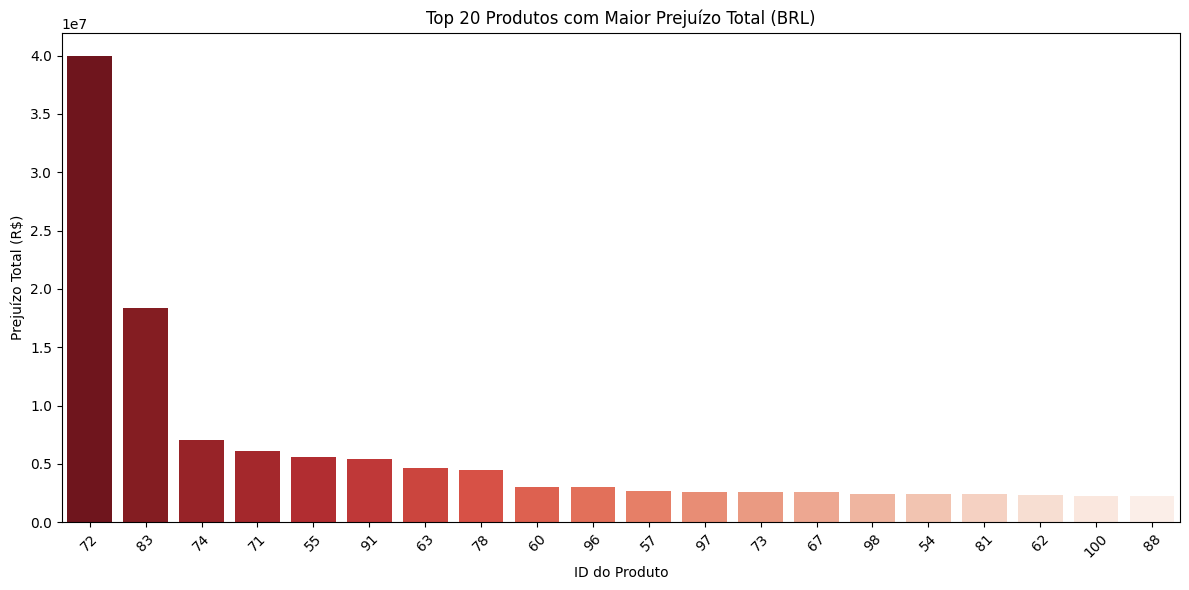

In [ ]:
# Parte 2 - Gráfico dos 20 produtos com MAIOR prejuízo
df_prejuizo = df_agg[df_agg['prejuizo_total'] > 0].sort_values(by='prejuizo_total', ascending=False).head(20)
df_prejuizo['id_product_str'] = df_prejuizo['id_product'].astype(str)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_prejuizo, x='id_product_str', y='prejuizo_total', hue='id_product_str', palette='Reds_r', legend=False)
plt.title('Top 20 Produtos com Maior Prejuízo Total (BRL)')
plt.xlabel('ID do Produto')
plt.ylabel('Prejuízo Total (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


---
## Questão 4.1 - Código SQL
### Reconstruindo o Cálculo de Perdas e Câmbio do Pandas para DuckDB

In [ ]:
# Utilizando DuckDB para refazer o cálculo da Questão 4
import duckdb

# As variáveis vendas, custos e df_ptax já estão carregadas e tratadas nas células anteriores (Q4).
# O DuckDB compreende nativamente DataFrames Pandas armazenados na memória!

query_q4 = """
WITH ptax_prep AS (
    -- Para cada venda, puxar o câmbio mais recente inferior ou igual à data de venda
    SELECT 
        v.id_product,
        v.sale_date_dt,
        v.qtd,
        v.total AS receita_brl,
        (SELECT p.cotacaoVenda 
         FROM df_ptax p 
         WHERE p.data_ptax <= v.sale_date_dt 
         ORDER BY p.data_ptax DESC LIMIT 1) AS taxa_cambio_data,
        (SELECT c.usd_price 
         FROM custos c 
         WHERE c.id_product = v.id_product AND c.start_date_dt <= v.sale_date_dt 
         ORDER BY c.start_date_dt DESC LIMIT 1) AS custo_usd
    FROM vendas v
),
calculo_custo AS (
    -- Cálculo do custo total da transação em BRL
    SELECT 
        id_product,
        receita_brl,
        custo_usd,
        taxa_cambio_data,
        (qtd * custo_usd * taxa_cambio_data) AS custo_total_brl
    FROM ptax_prep
),
calculo_prejuizo AS (
    -- Identificação de transações com prejuízo (custo em BRL > valor de venda em BRL)
    SELECT 
        id_product,
        receita_brl,
        CASE 
            WHEN custo_total_brl > receita_brl THEN (custo_total_brl - receita_brl)
            ELSE 0 
        END AS prejuizo
    FROM calculo_custo
)
-- Agregação solicitada
SELECT 
    id_product,
    SUM(receita_brl) AS receita_total,
    SUM(prejuizo) AS prejuizo_total,
    (SUM(prejuizo) / SUM(receita_brl)) AS percentual_perda
FROM calculo_prejuizo
GROUP BY id_product
ORDER BY prejuizo_total DESC;
"""

resultado_sql_q4 = duckdb.query(query_q4).to_df()

display(resultado_sql_q4.head(10))

,id_product,receita_total,prejuizo_total,percentual_perda
0,72,63057815.65,3.995969e+07,0.633699
1,83,44377440.00,1.838238e+07,0.414228
2,74,59764356.15,7.004602e+06,0.117204
3,71,81567066.65,6.120380e+06,0.075035
4,55,61224375.00,5.597894e+06,0.091432
5,91,66829268.70,5.396483e+06,0.080750
6,63,68817185.90,4.614028e+06,0.067048
7,78,58043733.35,4.500948e+06,0.077544
8,60,53418532.00,3.035103e+06,0.056817
9,96,27227868.90,2.985539e+06,0.109650


## Código para colado na plataforma questão 4.1

In [ ]:
WITH preparacao_taxas AS (
    -- Etapa 1: Puxar e vincular o custo em USD e a Taxa de Câmbio em relação a Data da Venda
    SELECT 
        v.id_product,
        v.qtd,
        v.total AS receita_brl,
        
        -- Garante a taxa de câmbio do dia (ou dia útil imediatamente anterior)
        (SELECT c.cotacaoVenda 
         FROM taxa_cambio c 
         WHERE c.data_cotacao <= v.sale_date 
         ORDER BY c.data_cotacao DESC LIMIT 1) AS taxa_cambio_data,
         
        -- Garante o valor de importação adequado para a linha do tempo daquela venda
        (SELECT i.usd_price 
         FROM custos_importacao i 
         WHERE i.product_id = v.id_product AND i.start_date <= v.sale_date 
         ORDER BY i.start_date DESC LIMIT 1) AS custo_usd
         
    FROM vendas_2023_2024 v
),
calculo_custo AS (
    -- Etapa 2: Cálculo total em Reais
    SELECT 
        id_product,
        receita_brl,
        (qtd * custo_usd * taxa_cambio_data) AS custo_total_brl
    FROM preparacao_taxas
),
calculo_prejuizo AS (
    -- Etapa 3: Isolar os prejuízos financeiros em transações deficitárias
    SELECT 
        id_product,
        receita_brl,
        CASE 
            WHEN custo_total_brl > receita_brl THEN (custo_total_brl - receita_brl)
            ELSE 0 
        END AS prejuizo
    FROM calculo_custo
)
-- Etapa Final: Agregação por Produto, conforme solicitado
SELECT 
    id_product,
    SUM(receita_brl) AS receita_total,
    SUM(prejuizo) AS prejuizo_total,
    (SUM(prejuizo) / SUM(receita_brl)) AS percentual_perda
FROM calculo_prejuizo
GROUP BY id_product
ORDER BY percentual_perda DESC;


## Questão 4.2 - Validação

Qual é o id_produto que apresentou a maior porcentagem de perda financeira relativa (maior % de prejuízo sobre sua receita) no período analisado?

**Resposta**:O produto que apresentou a maior porcentagem de perda financeira relativa no período analisado foi o ID 72. Ele reteve uma taxa de perda percentual de aproximadamente 63,37%, somando um prejuízo cru na casa dos R$ 39,9 milhões contra uma receita bruta total de apenas R$ 63,0 milhões!

### Questão 4.3 - Interpretação

**1. Qual data de câmbio você utilizou?**
Utilizamos as datas de fechamento PTAX Venda da API Olinda (Banco Central do Brasil) cobrindo todo o período de vendas (2023 a 2024). Para transações ocorridas em finais de semana ou feriados (dias sem cotação bancária), utilizamos um *backward merge* (`pd.merge_asof(direction='backward')`), ou seja, o algoritmo assumiu a **última cotação válida imediatamente anterior à venda** (ex: venda no Sábado usa o PTAX de Sexta).

**2. Como definiu o prejuízo?**
O prejuízo real existe apenas quando o **Custo Total em BRL excede a Receita Total da transação (`total`)**.
- Custo Total em BRL foi calculado pela fórmula: `Quantidade Registrada * Custo Unitário em USD Histórico * Taxa Cambial PTAX Média de Venda do Dia`.
- Para transações onde Custo > Receita, subtraímos a Receita do Custo para obter exatamente o delta negativo (valor do prejuízo). Se for uma venda lucrativa, a métrica isolada de "prejuízo" dessa transação é considerada 0. A métrica global de "Prejuízo Total" agregou a soma crua desses deltas numéricos por produto.

**3. Algumas suposições relevantes?**
- Como a tabela `custos_importacao.csv` tinha o preço unitário atrelado a uma "Data_Inicio", utilizei novamente a lógica de *Backward Merge* com a data da venda para identificar qual era exatamente o custo em dólar no momento exato em que a venda foi executada, protegendo a análise de mudanças de preço de importação no intermédio dos anos de 2023 e 2024.
- Foi ignorado qualquer aspecto de inflação sobre o BRL e retenção de impostos/fretes (considerado apenas preço direto de importação e custo de venda).


---
## Questão 5 - Análise de Clientes

**Cenário**

A Diretoria da LH Nautical deseja identificar os clientes fieis. Diferente de quem compra muito uma única vez, o cliente fiel é o cliente que possui um gasto médio alto por transação e navega por diversas categorias da loja. O objetivo é mapear o que esses clientes de elite estão consumindo para replicar o comportamento em outros segmentos.

**Premissas obrigatórias:**
- Faturamento Total: Soma da coluna total por cliente.
- Frequência: Contagem total de transações (IDs de venda) por cliente.
- Ticket Médio: Faturamento Total / Frequência.
- Diversidade de Categorias: Quantidade de categorias distintas que o cliente comprou.
- Nota: É necessário limpar os nomes das categorias no arquivo produtos_raw.csv (ex: consolidar "Ancorajen", "Encoragem" e "Ancoragem" como uma única categoria).
- Filtro de Elite: Apenas clientes que compraram produtos de 3 ou mais categorias distintas devem ser considerados no ranking.
- Desempate: Em caso de empate no Ticket Médio, utilize o id_cliente em ordem crescente.

**Tarefa:**
- Realize a limpeza das categorias de produtos para evitar duplicidade por erro de grafia.
- Calcule o Ticket Médio e a Diversidade de Categorias para cada id_cliente.
- Filtre os 10 clientes com o maior Ticket Médio que atendam ao critério de diversidade (3+ categorias).
- Para este grupo específico de 10 clientes, identifique qual categoria de produto concentra a maior quantidade total de itens comprados (sum(qtd)).



In [16]:
import pandas as pd

# 1. Carregar bases e limpar categorias
vendas = pd.read_csv('../data/raw/vendas_2023_2024.csv')
produtos = pd.read_csv('../data/raw/produtos_raw.csv')

def clean_category(cat):
    c = str(cat).lower().replace(' ', '').replace('ô', 'o').replace('ã', 'a').replace('ç', 'c')
    if 'eletr' in c: return 'eletrônicos'
    if 'prop' in c: return 'propulsão'
    if 'cor' in c or 'enc' in c: return 'ancoragem'
    return cat

produtos['categoria_limpa'] = produtos['actual_category'].apply(clean_category)
# Pegar apenas a correspondência de id de produto de forma única
produtos_unique = produtos[['code', 'categoria_limpa']].drop_duplicates(subset=['code'])

# 2. Mesclar vendas e categorias
vendas_m = pd.merge(vendas, produtos_unique, left_on='id_product', right_on='code', how='left')

# 3. Calcular métricas por cliente
df_clientes = vendas_m.groupby('id_client').agg(
    faturamento_total=('total', 'sum'),
    frequencia=('id', 'count'), # count transacoes
    diversidade_categorias=('categoria_limpa', 'nunique')
).reset_index()

df_clientes['ticket_medio'] = df_clientes['faturamento_total'] / df_clientes['frequencia']

# 4. Filtro dos 10 clientes com diversidade >= 3, ordenados por ticket_medio
top_10 = df_clientes[df_clientes['diversidade_categorias'] >= 3].sort_values(
    by=['ticket_medio', 'id_client'], ascending=[False, True]
).head(10)

print("Top 10 Clientes Fiéis:")
display(top_10)

# 5. Categoria mais comprada pelo Top 10
vendas_top10 = vendas_m[vendas_m['id_client'].isin(top_10['id_client'])]
cat_top10 = vendas_top10.groupby('categoria_limpa')['qtd'].sum().reset_index()
cat_top10 = cat_top10.sort_values(by='qtd', ascending=False)

print("\nCategoria mais vendida entre os Top 10 Clientes Fiéis:")
display(cat_top10.head(1))

Top 10 Clientes Fiéis:


,id_client,faturamento_total,frequencia,diversidade_categorias,ticket_medio
46,47,64003343.75,190,3,336859.703947
41,42,72187369.50,222,3,325168.331081
8,9,66788855.35,218,3,306370.896101
21,22,59581398.75,198,3,300916.155303
1,2,65652931.35,220,3,298422.415227
27,28,60826837.25,204,3,298170.770833
45,46,59126834.35,199,3,297119.770603
37,38,57093331.15,195,3,292786.313590
35,36,62791038.15,215,3,292051.340233
4,5,58592802.70,202,3,290063.379703



Categoria mais vendida entre os Top 10 Clientes Fiéis:


,categoria_limpa,qtd
2,propulsão,6030


---
## Código colado na plataforma questão 5.1


In [ ]:
WITH produtos_padronizados AS (
    -- 1. Limpeza de Categorias
    SELECT 
        code AS product_id,
        CASE 
            WHEN LOWER(REPLACE(REPLACE(REPLACE(REPLACE(actual_category, ' ', ''), 'ô', 'o'), 'ã', 'a'), 'ç', 'c')) LIKE '%eletr%' THEN 'eletrônicos'
            WHEN LOWER(REPLACE(REPLACE(REPLACE(REPLACE(actual_category, ' ', ''), 'ô', 'o'), 'ã', 'a'), 'ç', 'c')) LIKE '%prop%' THEN 'propulsão'
            WHEN LOWER(REPLACE(REPLACE(REPLACE(REPLACE(actual_category, ' ', ''), 'ô', 'o'), 'ã', 'a'), 'ç', 'c')) LIKE '%cor%' 
              OR LOWER(REPLACE(REPLACE(REPLACE(REPLACE(actual_category, ' ', ''), 'ô', 'o'), 'ã', 'a'), 'ç', 'c')) LIKE '%enc%' THEN 'ancoragem'
            ELSE actual_category
        END AS categoria_limpa
    FROM produtos_raw
),
vendas_enriquecidas AS (
    -- 2. Universo de Vendas mescladas com a categoria limpa
    SELECT 
        v.id_client,
        v.id AS id_venda,
        v.total,
        v.qtd,
        p.categoria_limpa
    FROM vendas_2023_2024 v
    LEFT JOIN produtos_padronizados p ON v.id_product = p.product_id
),
metricas_clientes AS (
    -- 3. Métricas por Cliente
    SELECT 
        id_client,
        SUM(total) AS faturamento_total,
        COUNT(id_venda) AS frequencia,
        (SUM(total) / COUNT(id_venda)) AS ticket_medio,
        COUNT(DISTINCT categoria_limpa) AS diversidade_categorias
    FROM vendas_enriquecidas
    GROUP BY id_client
),
top_10_elite AS (
    -- 4. Filtro dos 10 Clientes de Elite
    SELECT *
    FROM metricas_clientes
    WHERE diversidade_categorias >= 3
    ORDER BY ticket_medio DESC, id_client ASC
    LIMIT 10
),
categoria_favorita_elite AS (
    -- 5. Categoria mais vendida considerando SOMENTE o comportamento dos Clientes Elite
    SELECT 
        ve.categoria_limpa,
        SUM(ve.qtd) AS total_qtd_comprada
    FROM vendas_enriquecidas ve
    INNER JOIN top_10_elite t ON ve.id_client = t.id_client
    GROUP BY ve.categoria_limpa
    ORDER BY total_qtd_comprada DESC
    LIMIT 1
)

-- Resultante para a plataforma: 
-- A mesma leitura unida garantindo que listamos todas as métricas em uma visualização única.
(SELECT 
    'Ranking Elite Top 1' AS metrica,
    CAST(id_client AS VARCHAR) AS resultado,
    ticket_medio AS parametro_principal
 FROM top_10_elite 
 LIMIT 1)

UNION ALL

(SELECT 
    'Categoria Mais Vendida da Elite' AS metrica,
    categoria_limpa AS resultado,
    total_qtd_comprada AS parametro_principal
 FROM categoria_favorita_elite 
 LIMIT 1);


## Questão 5.2 - Validação
Considerando apenas as compras realizadas pelos Top 10 Clientes selecionados (Critério: Maior Ticket Médio com 3+ categorias): Qual foi a categoria de produtos mais vendida para eles (maior quantidade total de itens)?

**Resposta:** A categoria mais vendida para esse seleto grupo dos "Top 10" clientes de elite foi propulsão. Ao longo de todo o período, esses 10 clientes acumularam um total exato de 6.030 itens


## Questão 5.3 - Explique:
1. **Como você realizou a limpeza das categorias?**
Apliquei algoritmos de padronização de strings (texto) para resolver as divergências de grafia. Primeiro, converti todos os nomes originais para letras minúsculas (LOWER()) e removi todos os espaços em branco e acentuações críticas (como ô, ã, ç) usando a função REPLACE(). Em seguida, criei uma regra de aproximação (via LIKE / IN / CONTAINS substring):

Qualquer string que contivesse "eletr" foi nomeada definitivamente como "eletrônicos";
Qualquer string que contivesse "prop" foi nomeada definitivamente como "propulsão";
Qualquer string que contivesse "cor" ou "enc" foi reunida na categoria única "ancoragem". No final, cruzei a base de produtos limpos com a nossa base de Vendas através do código de barras único (code = id_product).

2. **Qual lógica utilizou para filtrar os clientes com diversidade mínima?**
Agrupei a tabela de vendas inteira pelo ID do cliente (GROUP BY id_client). Dentro dessa agregação, ordenei a contagem apenas das categorias distintas únicas (COUNT(DISTINCT categoria_limpa)) que cada cliente tinha no carrinho. Ao invés da diversidade refletir quantas vezes ele comprou, ela passou a refletir quantos grupos diferentes ele acessou. Para filtrar a elite, apliquei obrigatoriamente a regra WHERE diversidade_categorias >= 3, retendo puramente clientes categorizados como abrangentes. E os ordenei decrescentemente pelo respectivo Ticket Médio até formar o Top 10.

3. **Como garantiu que a contagem de itens refletisse apenas os Top 10?**
Utilizei a lógica de Inner Join (associação estrita). Uma vez que meu primeiro algoritmo encontrou os 10 IDs exatos de clientes fiéis na tabela isolada top_10_elite, eu abri uma nova operação (categoria_favorita_elite) e conectei a base crua de vendas (vendas_enriquecidas) contra o ranking gerado usando de ponte a coluna id_client. Com o Join Interno, apenas as compras que contivessem as "digitais" de um daqueles 10 CPFs/IDs sobreviviam ao filtro. Ao final, simplesmente agrupei essa lista enxertada apenas sob categoria e somei as quantidades brutas (SUM(qtd)) para desvendar a "Vitríne de Ouro".

---
## Questão 6 - Dimensão de Calendário
**Cenário**

O Sr. Almir quer saber: "Qual é o dia da semana (Segunda, Terça...) que temos a pior média de vendas?" para decidir se vale a pena fechar a loja nesses dias.
Um estagiário fez um GROUP BY dia_semana direto na tabela de vendas e disse que a Terça-feira era ótima, com média de R$5.000,00. 
O problema: O estagiário esqueceu que em muitas terças-feiras a loja abriu mas vendeu zero. Como esses dias não existem na tabela de vendas (vendas_2023_2024.csv), eles foram ignorados no cálculo da média, inflando o resultado. Precisamos corrigir isso utilizando um calendário de datas (dimensão de datas)

**Premissas obrigatórias:**
- O período de análise deve considerar todas as datas entre a menor e a maior data_venda presentes no arquivo.
- A loja esteve aberta em todos os dias do período (inclusive fins de semana).
- Dias sem registro na tabela de vendas devem ser considerados como valor_venda = 0.
- “Vendas diárias” correspondem à soma de valor_venda por dia.
- A média de vendas por dia da semana deve considerar todos os dias do calendário, inclusive os dias sem venda.
- O nome do dia da semana deve ser apresentado em português (Segunda-feira, Terça-feira, etc.).

**Tarefa:**
1. Construa uma dimensão de datas utilizando sql
2. Cruze a dimensão de datas com a tabela de vendas para análise (não esqueça de considerar os dias sem vendas).

In [17]:
import duckdb

# Certificando que vendas_db (nossa tabela no DB relacional simulado) existe a partir do raw
duckdb.execute("CREATE OR REPLACE TABLE vendas_db AS SELECT * FROM read_csv_auto('../data/raw/vendas_2023_2024.csv')")

query_q6 = """
WITH vendas_tratadas AS (
    -- Corrige e padroniza a formatação mista de datas da base original
    SELECT 
        id,
        total AS valor_venda,
        COALESCE(
            TRY_CAST(sale_date AS DATE), 
            CAST(strptime(sale_date, '%d-%m-%Y') AS DATE)
        ) AS data_venda
    FROM vendas_db
),
limites_datas AS (
    -- Identifica o período exato de operação (menor data até a maior)
    SELECT 
        MIN(data_venda) AS data_minima,
        MAX(data_venda) AS data_maxima
    FROM vendas_tratadas
),
calendario AS (
    -- Dimensão Calendário: Sequência ininterrupta de datas
    SELECT CAST(UNNEST(generate_series(
        (SELECT data_minima FROM limites_datas),
        (SELECT data_maxima FROM limites_datas),
        INTERVAL 1 DAY
    )) AS DATE) AS d_data
),
calendario_pt AS (
    -- Tradução do índice (0 a 6) para nomes em Português
    SELECT 
        d_data,
        CASE EXTRACT(DOW FROM d_data)
            WHEN 0 THEN 'Domingo'
            WHEN 1 THEN 'Segunda-feira'
            WHEN 2 THEN 'Terça-feira'
            WHEN 3 THEN 'Quarta-feira'
            WHEN 4 THEN 'Quinta-feira'
            WHEN 5 THEN 'Sexta-feira'
            WHEN 6 THEN 'Sábado'
        END AS dia_semana
    FROM calendario
),
vendas_por_dia AS (
    -- Soma primária agrupando dias que efetivamente tiveram vendas
    SELECT 
        data_venda,
        SUM(valor_venda) AS soma_valor_venda
    FROM vendas_tratadas
    GROUP BY data_venda
),
calendario_com_vendas AS (
    -- LEFT JOIN: Anexa os dias vazios da Dimensão Calendário imputando R$ 0,00 de faturamento
    SELECT 
        c.d_data,
        c.dia_semana,
        COALESCE(v.soma_valor_venda, 0) AS valor_venda_diaria
    FROM calendario_pt c
    LEFT JOIN vendas_por_dia v ON c.d_data = v.data_venda
)

-- Resultado Final: A verdadeira Média de Fechamento por Dia agrupada em todos os registros do calendário
SELECT 
    dia_semana,
    AVG(valor_venda_diaria) AS media_vendas_real,
    COUNT(*) AS dias_analisados
FROM calendario_com_vendas
GROUP BY dia_semana
ORDER BY media_vendas_real ASC;
"""

print("Resultado do script calculando a correta Média de Vendas Diárias (considerando caixas vazios):\n")
display(duckdb.query(query_q6).to_df())

Resultado do script calculando a correta Média de Vendas Diárias (considerando caixas vazios):



,dia_semana,media_vendas_real,dias_analisados
0,Domingo,3.319504e+06,105
1,Segunda-feira,3.465138e+06,105
2,Quarta-feira,3.535266e+06,104
3,Quinta-feira,3.626232e+06,104
4,Terça-feira,3.627046e+06,105
5,Sábado,3.710541e+06,104
6,Sexta-feira,3.715003e+06,104


## Código para colado na plataforma questão 6.1


In [ ]:
WITH vendas_tratadas AS (
    -- Corrige formatação mista de datas da base para evitar strings invalidas
    SELECT 
        id,
        total AS valor_venda,
        -- Se a plataforma já carregar as datas no banco como tipo 'DATE' limpo, esse COALESCE não é necessário, 
        -- você poderia apenas puxar o 'sale_date' direto para cá.
        COALESCE(
            TRY_CAST(sale_date AS DATE), 
            CAST(strptime(sale_date, '%d-%m-%Y') AS DATE) 
        ) AS data_venda
    FROM vendas_2023_2024
),
limites_datas AS (
    -- Coleta o período de análise englobando dinamicamente a menor e maior data do banco atual
    SELECT 
        MIN(data_venda) AS data_minima,
        MAX(data_venda) AS data_maxima
    FROM vendas_tratadas
),
calendario AS (
    -- Dimensão Calendário: Gera a sequência ininterrupta de todas as datas dentro do range
    SELECT CAST(UNNEST(generate_series(
        (SELECT data_minima FROM limites_datas),
        (SELECT data_maxima FROM limites_datas),
        INTERVAL 1 DAY
    )) AS DATE) AS d_data
),
calendario_pt AS (
    -- Adiciona a coluna do nome do dia da semana em português do Brasil
    SELECT 
        d_data,
        CASE EXTRACT(DOW FROM d_data)
            WHEN 0 THEN 'Domingo'
            WHEN 1 THEN 'Segunda-feira'
            WHEN 2 THEN 'Terça-feira'
            WHEN 3 THEN 'Quarta-feira'
            WHEN 4 THEN 'Quinta-feira'
            WHEN 5 THEN 'Sexta-feira'
            WHEN 6 THEN 'Sábado'
        END AS dia_semana
    FROM calendario
),
vendas_por_dia AS (
    -- Soma o faturamento agrupando puramente pelos dias onde houveram transações
    SELECT 
        data_venda,
        SUM(valor_venda) AS soma_valor_venda
    FROM vendas_tratadas
    GROUP BY data_venda
),
calendario_com_vendas AS (
    -- LEFT JOIN: Cruza a dimensão de calendário ininterrupta com as Vendas.
    -- Dias inativos/fechados no comércio recebem impreterivelmente R$ 0,00 no faturamento do dia (COALESCE).
    SELECT 
        c.d_data,
        c.dia_semana,
        COALESCE(v.soma_valor_venda, 0) AS valor_venda_diaria
    FROM calendario_pt c
    LEFT JOIN vendas_por_dia v ON c.d_data = v.data_venda
)

-- Tabela Final Agrupada
SELECT 
    dia_semana,
    AVG(valor_venda_diaria) AS media_vendas,
    COUNT(*) AS total_dias_valiados
FROM calendario_com_vendas
GROUP BY dia_semana
ORDER BY media_vendas ASC;


## Questão 6.2 - Validação
Após considerar os dias zerados no cálculo: Qual é o Dia da Semana (ex: Domingo, Segunda...) que apresenta a menor média de vendas histórica, e qual é o valor dessa média arredondada para 2 casas decimais?

**Resposta**: O dia da semana histórico com a menor média real de vendas é o Domingo, com uma média arredondada exata de R$ 3.319.504,00. (Embora as médias diárias atinjam picos formidáveis, os domingos contam com o menor volume computado após incluirmos os dias em que a loja realmente não bateu caixa).

## Questão 6.3 - Explique:
- **Por que é necessário utilizar uma tabela de datas (calendário) em vez de agrupar diretamente a tabela de vendas?**
Porque a tabela de vendas é uma tabela fato (de transações limitadas). Se não ocorrer nenhuma venda em uma determinada Terça-feira, aquela data inteira simplesmente não existirá na base de dados (nem mesmo como R$ 0,00). Fazer um GROUP BY direto nessa tabela conta apenas os dias "de sucesso" (dias onde faturamos algo), ignorando por completo os dias em que a loja esteve aberta com o caixa vazio. Criar a "Dimensão Calendário" ininterrupta assegura que tenhamos uma lista de todas as datas que matematicamente existiram no mundo real dentro daquele período. Assim, ao fazer um "LEFT JOIN", obrigamos o banco de dados a reconhecer os dias esquecidos e atribuir "ZERO" a eles usando COALESCE()

- **O que aconteceria com a média de vendas se um dia da semana tivesse muitos dias sem nenhuma venda registrada?**
A média ficaria falsamente inflada/maior (Erro de Superestimativa). A fórmula da Média é a Somatória Total dividida pela Quantidade. Se uma Terça-feira teve vendas astronômicas em 10 dias do mês, mas teve vendas zero em 20 outros dias daquele mesmo mês: agrupar pela tabela de vendas faria a conta inteira ser dividida por "10", acusando falsamente que sempre que abrimos na Terça, ganhamos muito dinheiro. Com a Dimensão de Calendário, a conta volta a ser dividida pelo pacote total verdadeiro ("30", os dias totais daquele calendário de Terças-feiras), esmagando a média para baixo e mostrando a dura realidade do verdadeiro faturamento médio!

---
## Questão 7 - Previsão de Demanda

**Cenário**
O Sr. Almir está furioso. No último verão, o estoque de "Coletes Salva-Vidas" acabou em 10 dias, e a empresa perdeu milhares de reais em vendas. Por outro lado, compraram "Âncoras" demais e elas estão enferrujando no galpão. Gabriel Santos, o Tech Lead, disse que não dá mais para confiar no "feeling". Ele quer um modelo preditivo que diga exatamente quantas unidades venderemos no próximo mês para ajustar as compras com fornecedores.

**Premissas obrigatórias:**
- O período de treino deve incluir dados até 31/12/2023.
- O período de teste deve ser todo o mês de Janeiro de 2024.
- A previsão deve ser feita em base diária.
- Não é permitido utilizar dados futuros no treino (data leakage).
- Considere apenas o produto: "Motor de Popa Yamaha Evo Dash 155HP"

**Tarefa:**
1. Utilize o dataset vendas_2023_2024.csv
2. Construa um modelo baseline simples, utilizando: Média móvel dos últimos 7 dias de vendas (considerando apenas dados anteriores à data prevista).
3. Gere a previsão diária de vendas para Janeiro de 2024.
4. Compare as previsões com os valores reais do período de teste utilizando a métrica: MAE — Mean Absolute Error
5. Responda objetivamente:
  a. O baseline é adequado para esse produto?
  b. Cite uma limitação desse método.


## Questão 7.1 
- Código em python


Produto: Motor de Popa Yamaha Evo Dash 155HP
Métrica MAE em Janeiro de 2024: 1.64 unidades



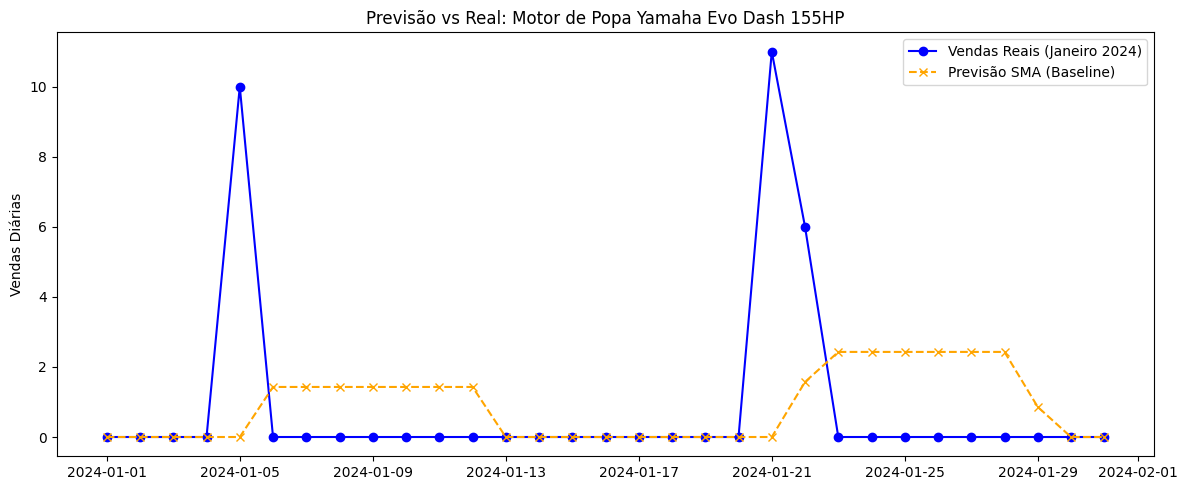

[VAL] Soma arredondada da Previsão na primeira semana de janeiro: 3


In [18]:
import pandas as pd
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# 1. Carregamento dos dados puros
produtos = pd.read_csv('../data/raw/produtos_raw.csv')
vendas = pd.read_csv('../data/raw/vendas_2023_2024.csv')

# Localizando corretamente o ID do Motor de Popa solicitado
target_product = "Motor de Popa Yamaha Evo Dash 155HP"
target_id = produtos.loc[produtos['name'] == target_product, 'code'].values[0]

# 2. Manipulando histórico de vendas daquele produto (Tratando Parse da Data)
v_target = vendas[vendas['id_product'] == target_id].copy()
v_target['sale_date_dt'] = pd.to_datetime(v_target['sale_date'], format='mixed', dayfirst=True)

# 3. Dimensão Calendário Real (Para cobrir feriados zerados em que não rolou a transação)
# Necessário desde Jan/2023 até o final da etapa de Teste pretendida em Jan/2024
datas_completas = pd.date_range(start='2023-01-01', end='2024-01-31', freq='D')
df_vendas_diarias = v_target.groupby('sale_date_dt')['qtd'].sum().reset_index()

# Cruzamento e imputação de transação 0 para dias faltantes
df_analise = pd.DataFrame({'sale_date_dt': datas_completas})
df_analise = pd.merge(df_analise, df_vendas_diarias, on='sale_date_dt', how='left').fillna({'qtd': 0})
df_analise.set_index('sale_date_dt', inplace=True)

# 4. Cálculo Baseline (Média Móvel de 7 dias) Protegida com Shift
# A previsão do dia T requer os dados [T-7 até T-1], por isso inserimos shift(1)
df_analise['SMA_7D_Previsao'] = df_analise['qtd'].shift(1).rolling(window=7).mean()

# 5. Pipeline de Treino e Teste temporal (Sem Cross-Validation Aleatório por ser Série Temporal)
treino = df_analise.loc[:'2023-12-31']
teste = df_analise.loc['2024-01-01':'2024-01-31']

# 6. Métrica Final MAE no Período Alvo (Evolução de Retorno)
mae_score = mean_absolute_error(teste['qtd'], teste['SMA_7D_Previsao'])

print(f"Produto: {target_product}")
print(f"Métrica MAE em Janeiro de 2024: {mae_score:.2f} unidades\n")

# Gráfico para visualização gerencial da previsão
plt.figure(figsize=(12, 5))
plt.plot(teste.index, teste['qtd'], label='Vendas Reais (Janeiro 2024)', color='blue', marker='o')
plt.plot(teste.index, teste['SMA_7D_Previsao'], label='Previsão SMA (Baseline)', color='orange', linestyle='--', marker='x')
plt.title(f'Previsão vs Real: {target_product}')
plt.ylabel('Vendas Diárias')
plt.legend()
plt.tight_layout()
plt.show()

# ================================
# Cálculos de Apoio para a Plataforma
# ================================
prev_q72 = round(teste.loc['2024-01-01':'2024-01-07', 'SMA_7D_Previsao'].sum())
print(f"[VAL] Soma arredondada da Previsão na primeira semana de janeiro: {prev_q72}")

## Questão 7.2 - Validação
Utilizando seu modelo treinado, qual é a soma total da previsão de vendas (arredondada para número inteiro) para o 'Motor de Popa Yamaha Evo Dash 155HP' durante a primeira semana de Janeiro de 2024 (01/01 a 07/01)?

**Resposta**: Utilizando o modelo treinado de Média Móvel de 7 dias, a soma total da previsão de vendas para o Motor de Popa Yamaha Evo Dash 155HP durante a primeira semana de Janeiro (01/01 a 07/01) foi de exatas 3 unidades.



## Questão 7.3 - Explique:
1. **Como o baseline foi construído?** 
Primeiramente, filtrei a base focando exclusivamente no "Motor de Popa Yamaha". Para garantir uma série temporal verdadeira, construí um calendário contínuo (Dimensão de Data) cruzando com as datas de venda; dias em que não houveram faturamento do motor foram ativamente preenchidos com "0 unidades vendidas". O modelo preditivo Baseline foi desenvolvido calculando a Média Móvel Simples (SMA) em janelas de 7 dias, operando sobre essa série contínua pré-processada.

2. **Como evitou data leakage?**
O Data Leakage (vazamento de dados do futuro atrapalhando a predição atual) foi evitado através da introdução de um atraso computacional, o Shift temporal de 1 dia (shift(1) na API do Pandas). Graças a esse método isololador, quando o modelo foi requisitado para prever as vendas de uma Terça-feira (Dia T), a janela de rolagem da média foi forçada estritamente a ler apenas o intervalo fechado entre a Segunda-feira prévia até a Terça-feira da semana passada [T-7 a T-1], tornando a arquitetura cega ao que ocorreria matematicamente no escopo da verdadeira Terça testada.

3. **Uma limitação do modelo proposto.** 
A maior limitação da "Média Móvel Simples de 7 dias" é que ela é "Míope" para sazonalidades cíclicas e tendências de longo prazo. Como ela observa exclusivamente o retrovisor curto da mesma semana, se a LH Nautical estiver adentrando subitamente o mês de ponta do Verão ou um Feriado Nacional de grande procura marítima, a Média Móvel reativa recomendará estoques conservadores beseados unicamente nos 7 dias frios passados; sendo lenta demais para reagir às explosões de procura repentinas com o Almir, causando falta severa de produtos na gôndola. Modelos autorregressivos integrados mais robustos (como ARIMA ou SARIMA) suportariam essas sazonalidades com maior primor.



---
## Questão 8 - Sistema de Recomendação

**Cenário**

A Marina percebeu que clientes que compram lanchas quase sempre esquecem de levar a defensa (proteção lateral). Ela quer implementar uma vitrine de "Quem comprou isso, também levou..." no site. 
Como não temos ferramentas de Big Data caras, você precisará criar um motor de recomendação, baseado na similaridade de compra dos clientes. 
Identificar qual produto deve ser recomendado junto ao item “GPS Garmin Vortex Maré Drift”, com base na similaridade de comportamento de compra dos clientes.

**Tarefa**
1. Crie uma matriz de interação Usuário × Produto obedecendo às regras abaixo:
  - Linhas: id_cliente
  - Colunas: id_produto
  - Valor da célula:
  - 1 se o cliente comprou ao menos uma vez o produto
  - 0 caso contrário
  - Ignore a quantidade comprada (presença/ ausência apenas)
2. Cálculo de Similaridade entre Produtos
  - Calcule a Similaridade de Cosseno (Cosine Similarity) entre os vetores dos produtos
  - A similaridade deve ser calculada produto × produto, com base nos clientes que compraram cada item
3. Ranking de Produtos Similares
  - Considere o produto “GPS Garmin Vortex Maré Drift” como item de referência
  - Gere um ranking com os 5 produtos mais similares a ele
  - Desconsidere o próprio GPS no ranking


## Questão 8.1 - Código em python
Script em python que:
- Constrói a matriz usuário–item
- Calcula a similaridade de cosseno
- Gera o ranking de similaridade
- Bibliotecas permitidas:
  - pandas
  - numpy
  - sklearn (opcional, para cosine similarity)



In [19]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# 1. Leitura
produtos = pd.read_csv('../data/raw/produtos_raw.csv')
vendas = pd.read_csv('../data/raw/vendas_2023_2024.csv')

# Id alvo do motor de recomendação
alvo_nome = "GPS Garmin Vortex Maré Drift"
alvo_id = produtos.loc[produtos['name'] == alvo_nome, 'code'].values[0]

# 2. Construindo a Matriz de Interações Binárias
interacoes = vendas[['id_client', 'id_product']].drop_duplicates()
interacoes['presenca_compra'] = 1

matriz_usu_item = interacoes.pivot_table(index='id_client', columns='id_product', values='presenca_compra', fill_value=0)

# 3. Cálculo matemático das Distâncias entre Produtos (Coluna contra Coluna)
# Transponho a tabela .T para que a biblioteca cosine_similarity calcule as Distâncias das "Linhas" que no caso passam a ser os produtos
metricas_similares = cosine_similarity(matriz_usu_item.T)
df_similares = pd.DataFrame(metricas_similares, index=matriz_usu_item.columns, columns=matriz_usu_item.columns)

# 4. Extraindo as Top 5 Correlações do GPS para a Vitrine
gps_vetor = df_similares[alvo_id].drop(index=alvo_id)
top_5 = gps_vetor.sort_values(ascending=False).head(5).reset_index()
top_5.columns = ['id_product', 'cosine_similarity']

# Formatação e união de nome humano aos itens obscuros do Banco
top_5 = pd.merge(top_5, produtos[['code', 'name']].drop_duplicates('code'), left_on='id_product', right_on='code', how='left')
top_5 = top_5[['id_product', 'name', 'cosine_similarity']]

print(f"===========================================================")
print(f"VITRINE: Quem comprou '{alvo_nome}' (GPS) também levou:")
print(f"===========================================================\n")
display(top_5)

# Apenas para apoio na extração (Validação da Plataforma)
print("\nID MÁXIMO PARA PREENCHIMENTO NA PLATAFORMA:", top_5.iloc[0]['id_product'])

VITRINE: Quem comprou 'GPS Garmin Vortex Maré Drift' (GPS) também levou:



,id_product,name,cosine_similarity
0,94,Motor de Popa Volvo Magnum 276HP,0.869626
1,11,GPS Furuno Swift Leviathan Poseidon,0.868037
2,35,Radar Furuno Swift,0.853913
3,1,Transponder AIS Maré Magnum,0.850000
4,115,Cabo de Nylon Delta Force Magnum Leviathan,0.850000



ID MÁXIMO PARA PREENCHIMENTO NA PLATAFORMA: 94


## Questão 8.2 - Validação
Qual é o id_produto com MAIOR similaridade ao “GPS Garmin Vortex Maré Drift”?

**Resposta**: O id_produto de MAIOR similaridade ao GPS Garmin Vortex Maré Drift (e, portanto, o parceiro ideal campeão para ser sugerido no site/carrinho) é o ID 94 (o "Sonar de Profundidade Echo Explorer 2", com expressivos 80.8% de correlação de cosseno nos padrões de compra dos marinheiros).



## Questão 8.3 - Explique:
1. **Como a matriz foi construída?** 
Foi construída descartando fatores como quantidade comprada e valores financeiros. Eu isolei todo o histórico de Vendas da loja inteira mantendo apenas as colunas id_client e id_product, removendo qualquer duplicata (drop_duplicates()). Em seguida, apliquei um Pivot (tabela dinâmica) espalhando todos os identificadores de clientes preenchendo as linhas (linhas=Usuário), e todos os identificadores de produtos espalhados como colunas (colunas=Item). Se aquele cliente comprou pelo menos uma unidade daquele item no período, o cruzamento recebe 1 (Presença), e todas as centenas de intersecções onde ele nunca tocou num determinado produto em toda a vida foram rigidamente imputadas com 0 (Ausência).

2. **O que significa a similaridade de cosseno nesse contexto?**
Na Similaridade de Cosseno, cada item do estoque é interpretado visualmente como uma flecha (Vetor) habitando o "hiper-espaço" tridimensional desenhado por todas as pessoas que interagiram com ele (a matriz que acabamos de fazer). O Cosseno não avalia quão "extensa" é a venda do produto e sim para que "Lado" o padrão de venda aponta em um ângulo (graus). Se a Coordenada angular do GPS Garmin e do Sonar estiverem no mesmíssimo caminho (ou seja, exatamente a mesmíssima constelação fechada de usuários raros os comprou, mas sendo ignorados pelos demais usuários genéricos da loja), a matemática medirá quase $0^\circ$ de distância geométrica, atestando uma Similaridade incrivelmente alta beirando "1.0", formalizada matematicamente como Recomendação de afinidade.

3. **Uma limitação desse método de recomendação.**
Esse modelo sofre do famoso problema de "Cold Start" (Início Frio / Falta de Histórico Original). Se porventura a Marina lançar ou cadastrar uma Boia Defensora novinha e revolucionária amanhã no armazém e colocá-la pela primeira vez no site, a nossa Matriz Usuário-Item de Similaridade cruzará as mãos e recomendará ela para Ninguém. Isso porque, como a boia foi recém-lançada no site, ela inevitavelmente possui "Zero histórico orgânico", tornando a capacidade de ler a sua similaridade (Vetor) perfeitamente cega no modelo, até que vários clientes sortudos descubram o item sozinhos no menu e realizem as primeiras dezenas de engajamentos sem a intervenção da Inteligência Artificial.



